# Cross-Company Ingredient Overlap Analysis

Deep dive into which ingredients are shared across companies, how companies cluster by shared raw materials, and where the biggest consolidation opportunities lie.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from itertools import combinations

matplotlib.rcParams['figure.figsize'] = (14, 7)
matplotlib.rcParams['font.size'] = 11
sns.set_style("whitegrid")

DB_PATH = "../data/db.sqlite"
conn = sqlite3.connect(DB_PATH)

# Load tables
company = pd.read_sql("SELECT * FROM Company", conn)
product = pd.read_sql("SELECT * FROM Product", conn)
bom = pd.read_sql("SELECT * FROM BOM", conn)
bom_component = pd.read_sql("SELECT * FROM BOM_Component", conn)
supplier = pd.read_sql("SELECT * FROM Supplier", conn)
supplier_product = pd.read_sql("SELECT * FROM Supplier_Product", conn)

# Build the full BOM view: BOM_Component -> BOM -> finished-good product -> company
bom_full = (
    bom_component
    .merge(bom, left_on="BOMId", right_on="Id")
    .merge(product.rename(columns={"Id": "FGId", "SKU": "FG_SKU", "CompanyId": "FG_CompanyId", "Type": "FG_Type"}),
           left_on="ProducedProductId", right_on="FGId")
    .merge(product.rename(columns={"Id": "RMId", "SKU": "RM_SKU", "CompanyId": "RM_CompanyId", "Type": "RM_Type"}),
           left_on="ConsumedProductId", right_on="RMId")
    .merge(company.rename(columns={"Id": "CoId", "Name": "CompanyName"}),
           left_on="FG_CompanyId", right_on="CoId")
)

def extract_ingredient(sku):
    """Parse ingredient name from SKU like 'RM-C28-glycerin-85e43afb'."""
    parts = sku.split("-")
    if len(parts) >= 4 and parts[0] == "RM":
        return "-".join(parts[2:-1])
    return sku

bom_full["ingredient"] = bom_full["RM_SKU"].apply(extract_ingredient)

print(f"Loaded {len(bom_full)} BOM-component rows across {bom_full['CompanyName'].nunique()} companies")
print(f"Unique ingredients: {bom_full['ingredient'].nunique()}")

Loaded 1528 BOM-component rows across 61 companies
Unique ingredients: 357


## 1. Company-Ingredient Matrix

Build a binary matrix: does company X use ingredient Y? This is the foundation for all overlap analysis.

In [2]:
# Binary matrix: company x ingredient
company_ingredient = (
    bom_full[["CompanyName", "ingredient"]]
    .drop_duplicates()
    .assign(used=1)
    .pivot_table(index="CompanyName", columns="ingredient", values="used", fill_value=0)
)

print(f"Matrix shape: {company_ingredient.shape[0]} companies x {company_ingredient.shape[1]} ingredients")
print(f"Sparsity: {1 - company_ingredient.values.sum() / company_ingredient.size:.1%} zeros")
print(f"Avg ingredients per company: {company_ingredient.sum(axis=1).mean():.1f}")
print(f"Avg companies per ingredient: {company_ingredient.sum(axis=0).mean():.1f}")

Matrix shape: 61 companies x 357 ingredients
Sparsity: 96.0% zeros
Avg ingredients per company: 14.4
Avg companies per ingredient: 2.5


## 2. Pairwise Company Overlap (Jaccard Similarity)

For every pair of companies, compute the Jaccard similarity of their ingredient sets: `|A ∩ B| / |A ∪ B|`. High Jaccard means the two companies use very similar ingredient portfolios — strong consolidation potential.

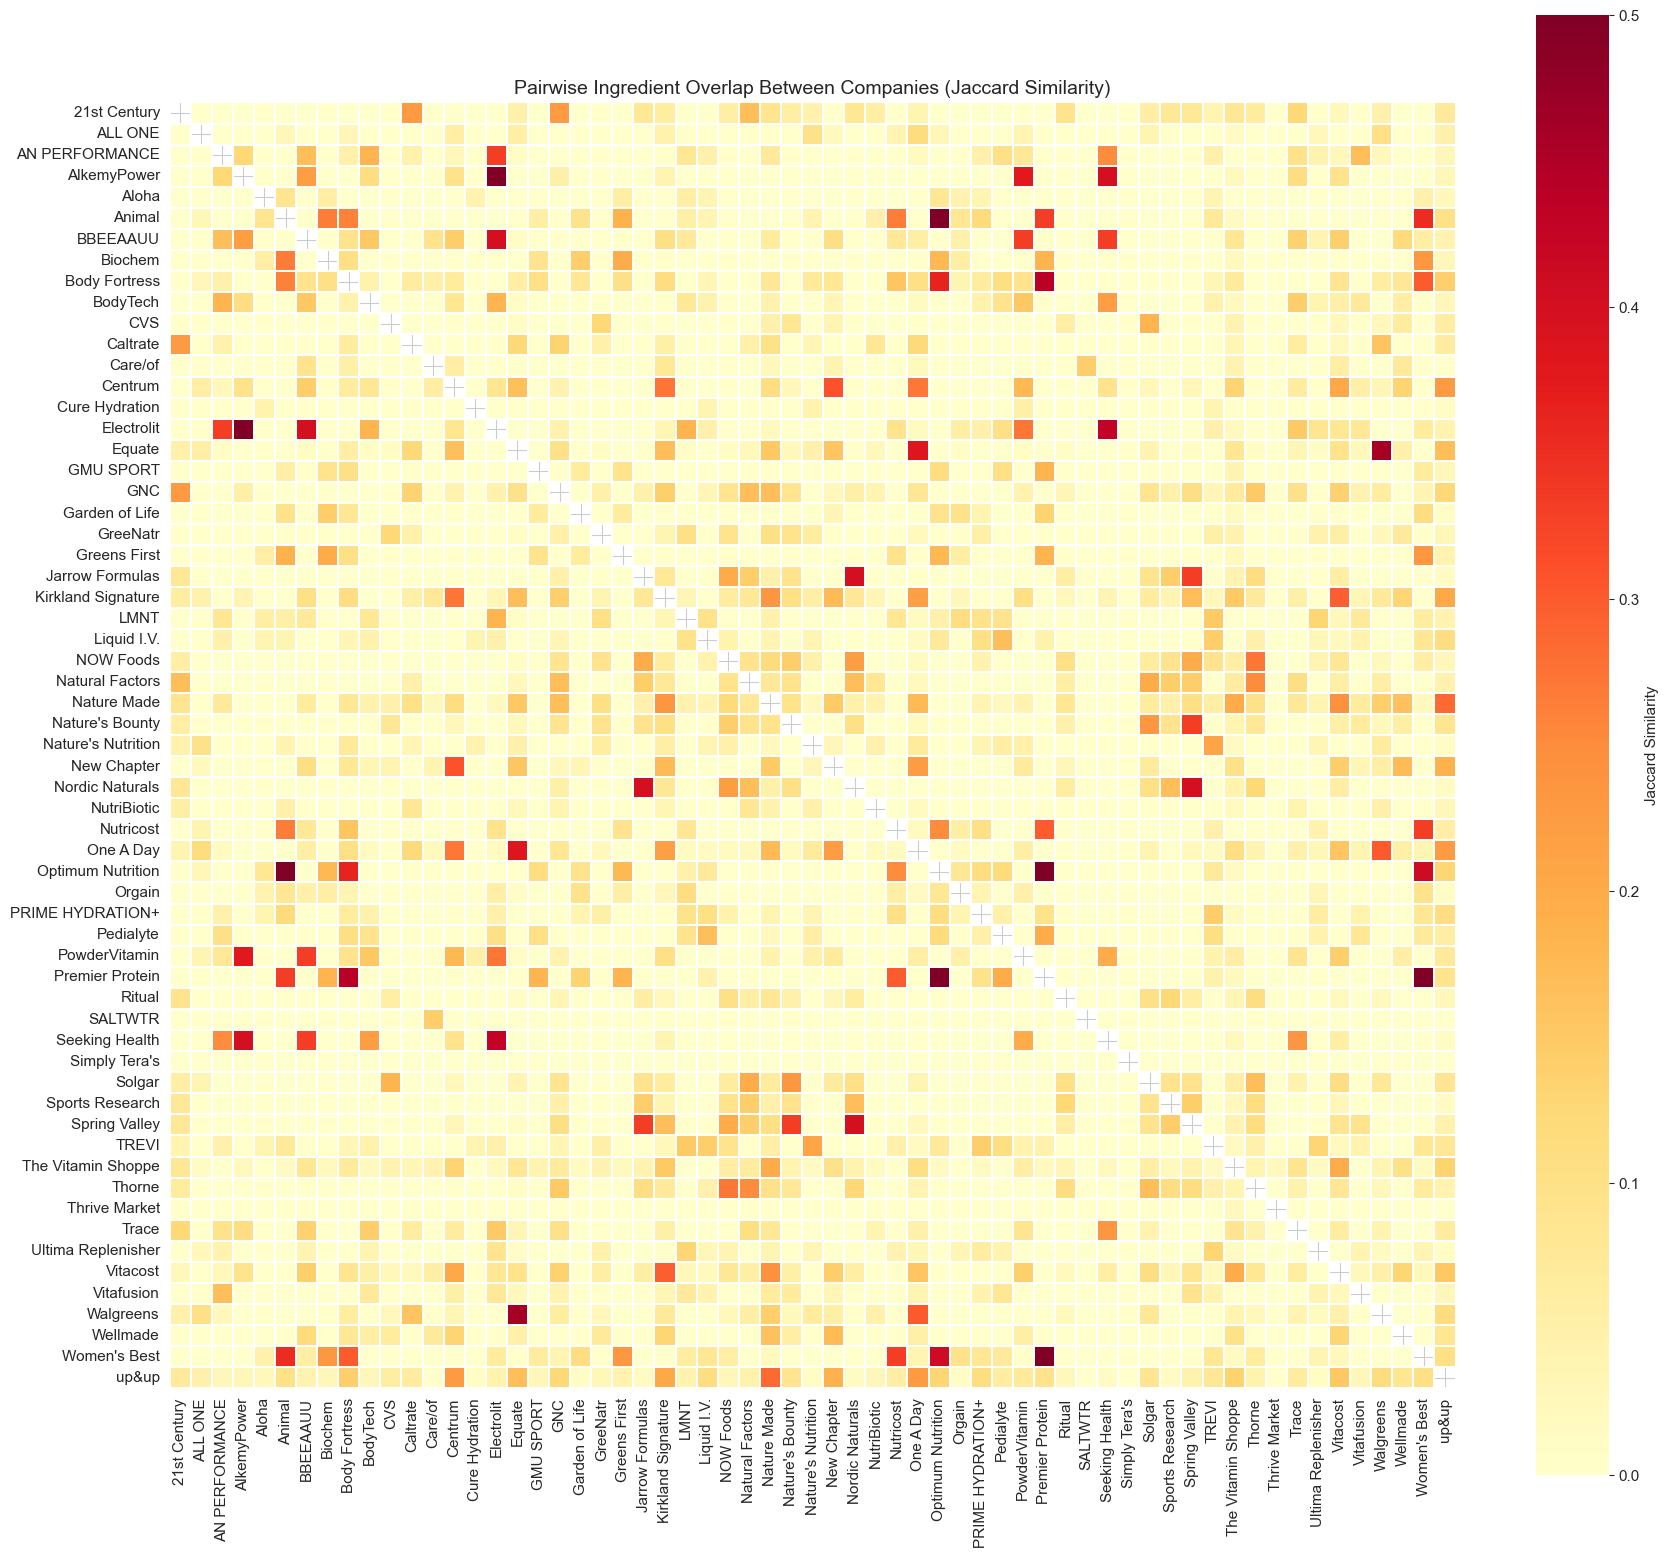

In [3]:
# Compute Jaccard similarity between all company pairs
mat = company_ingredient.values.astype(int)
companies_list = company_ingredient.index.tolist()
n = len(companies_list)

jaccard = np.zeros((n, n))
shared_count = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        intersection = np.sum(mat[i] & mat[j])
        union = np.sum(mat[i] | mat[j])
        jaccard[i, j] = intersection / union if union > 0 else 0
        shared_count[i, j] = intersection

jaccard_df = pd.DataFrame(jaccard, index=companies_list, columns=companies_list)
shared_df = pd.DataFrame(shared_count, index=companies_list, columns=companies_list)

# Heatmap of Jaccard similarity
fig, ax = plt.subplots(figsize=(18, 16))
mask = np.eye(n, dtype=bool)  # mask diagonal
sns.heatmap(jaccard_df, mask=mask, cmap="YlOrRd", vmin=0, vmax=0.5,
            square=True, linewidths=0.2, ax=ax,
            cbar_kws={"label": "Jaccard Similarity"})
ax.set_title("Pairwise Ingredient Overlap Between Companies (Jaccard Similarity)", fontsize=14)
plt.tight_layout()
plt.show()

Top 25 company pairs by ingredient overlap (Jaccard):


,Company A,Company B,Shared Ingredients,Jaccard Similarity,Union Size
320,Animal,Optimum Nutrition,10,0.588,17
1657,Premier Protein,Women's Best,6,0.545,11
1534,Optimum Nutrition,Premier Protein,7,0.500,14
188,AlkemyPower,Electrolit,3,0.500,6
880,Equate,Walgreens,34,0.459,74
484,Body Fortress,Premier Protein,7,0.438,16
823,Electrolit,Seeking Health,3,0.429,7
1552,Optimum Nutrition,Women's Best,7,0.412,17
353,BBEEAAUU,Electrolit,4,0.400,10
1098,Jarrow Formulas,Nordic Naturals,2,0.400,5


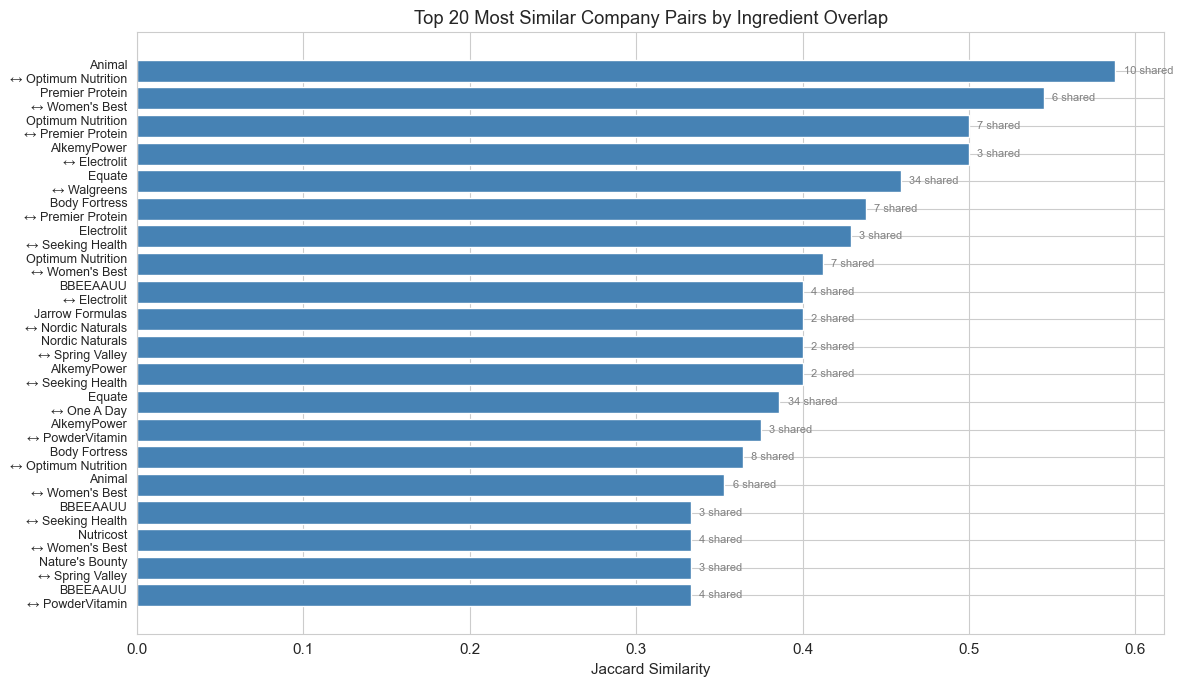

In [4]:
# Top 25 most similar company pairs
pairs = []
for i in range(n):
    for j in range(i + 1, n):
        pairs.append({
            "Company A": companies_list[i],
            "Company B": companies_list[j],
            "Shared Ingredients": int(shared_count[i, j]),
            "Jaccard Similarity": round(jaccard[i, j], 3),
            "Union Size": int(np.sum(mat[i] | mat[j]))
        })

pairs_df = pd.DataFrame(pairs).sort_values("Jaccard Similarity", ascending=False)
print("Top 25 company pairs by ingredient overlap (Jaccard):")
display(pairs_df.head(25))

fig, ax = plt.subplots(figsize=(12, 7))
top20 = pairs_df.head(20).copy()
top20["pair"] = top20["Company A"] + "\n\u2194 " + top20["Company B"]
ax.barh(range(len(top20)), top20["Jaccard Similarity"], color="steelblue")
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20["pair"], fontsize=9)
ax.set_xlabel("Jaccard Similarity")
ax.set_title("Top 20 Most Similar Company Pairs by Ingredient Overlap")
ax.invert_yaxis()
for i, (j, s) in enumerate(zip(top20["Jaccard Similarity"], top20["Shared Ingredients"])):
    ax.text(j + 0.005, i, f"{s} shared", va="center", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

## 3. Hierarchical Clustering of Companies by Ingredient Profile

Cluster companies based on their ingredient portfolios to reveal natural groupings — companies in the same cluster are the strongest candidates for joint procurement.

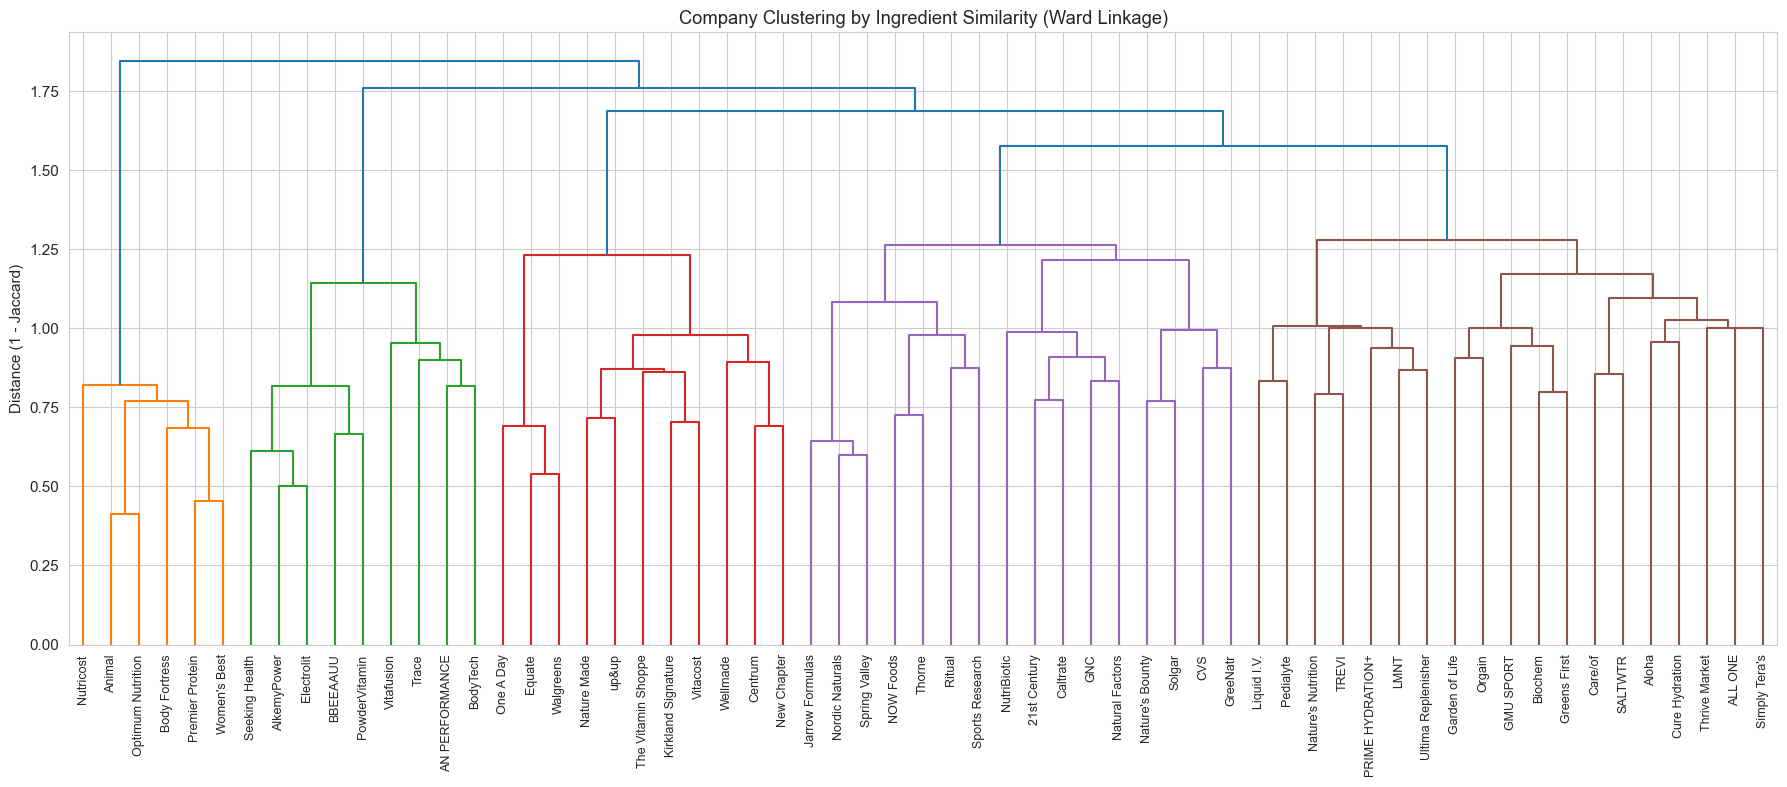


Companies grouped into 6 clusters:

  Cluster 1 (6 companies): Body Fortress, Women's Best, Optimum Nutrition, Nutricost, Animal, Premier Protein

  Cluster 2 (9 companies): PowderVitamin, Trace, BodyTech, Electrolit, BBEEAAUU, AlkemyPower, AN PERFORMANCE, Vitafusion, Seeking Health

  Cluster 3 (11 companies): One A Day, Kirkland Signature, Nature Made, up&up, Equate, The Vitamin Shoppe, Centrum, Vitacost, Walgreens, Wellmade, New Chapter

  Cluster 4 (16 companies): Solgar, Spring Valley, Ritual, Thorne, NutriBiotic, Sports Research, 21st Century, Nature's Bounty, Natural Factors, NOW Foods, CVS, Caltrate, GNC, Jarrow Formulas, Nordic Naturals, GreeNatr

  Cluster 5 (7 companies): Ultima Replenisher, TREVI, Nature's Nutrition, LMNT, Pedialyte, PRIME HYDRATION+, Liquid I.V.

  Cluster 6 (12 companies): Simply Tera's, Greens First, GMU SPORT, Cure Hydration, Care/of, Thrive Market, Orgain, Biochem, Aloha, ALL ONE, SALTWTR, Garden of Life


In [5]:
# Hierarchical clustering using Jaccard distance
jaccard_dist = 1 - jaccard
np.fill_diagonal(jaccard_dist, 0)
condensed = squareform(jaccard_dist)
Z = linkage(condensed, method="ward")

fig, ax = plt.subplots(figsize=(18, 8))
dend = dendrogram(Z, labels=companies_list, ax=ax, leaf_rotation=90, leaf_font_size=9,
                  color_threshold=0.7 * max(Z[:, 2]))
ax.set_ylabel("Distance (1 - Jaccard)")
ax.set_title("Company Clustering by Ingredient Similarity (Ward Linkage)")
plt.tight_layout()
plt.show()

# Cut into clusters
n_clusters = 6
cluster_labels = fcluster(Z, t=n_clusters, criterion="maxclust")
cluster_map = pd.DataFrame({"Company": companies_list, "Cluster": cluster_labels}).sort_values("Cluster")

print(f"\nCompanies grouped into {n_clusters} clusters:")
for c in sorted(cluster_map.Cluster.unique()):
    members = cluster_map[cluster_map.Cluster == c]["Company"].tolist()
    print(f"\n  Cluster {c} ({len(members)} companies): {', '.join(members)}")

## 4. Shared Ingredient Deep Dive

For each ingredient shared across 2+ companies, show the exact set of companies using it and the number of distinct BOMs it appears in.

In [6]:
# Detailed shared-ingredient table
ingredient_stats = (
    bom_full.groupby("ingredient")
    .agg(
        n_companies=("CompanyName", "nunique"),
        n_boms=("BOMId", "nunique"),
        n_raw_products=("RMId", "nunique"),
        companies=("CompanyName", lambda x: sorted(x.unique()))
    )
    .reset_index()
    .sort_values("n_companies", ascending=False)
)

shared = ingredient_stats[ingredient_stats.n_companies >= 2].copy()
print(f"Ingredients shared across 2+ companies: {len(shared)}")
print(f"Ingredients shared across 5+ companies: {(shared.n_companies >= 5).sum()}")
print(f"Ingredients shared across 10+ companies: {(shared.n_companies >= 10).sum()}")

# Top 30 most-shared ingredients
display(shared.head(30)[["ingredient", "n_companies", "n_boms", "n_raw_products"]])

Ingredients shared across 2+ companies: 143
Ingredients shared across 5+ companies: 51
Ingredients shared across 10+ companies: 14


,ingredient,n_companies,n_boms,n_raw_products
338,vitamin-d3-cholecalciferol,17,33,17
163,microcrystalline-cellulose,13,29,13
332,vitamin-c,13,24,13
53,citric-acid,12,26,12
101,gelatin,11,30,11
152,magnesium-stearate,11,30,11
351,zinc,11,17,11
140,magnesium,11,14,11
347,whey-protein-isolate,11,20,11
339,vitamin-e,10,19,10


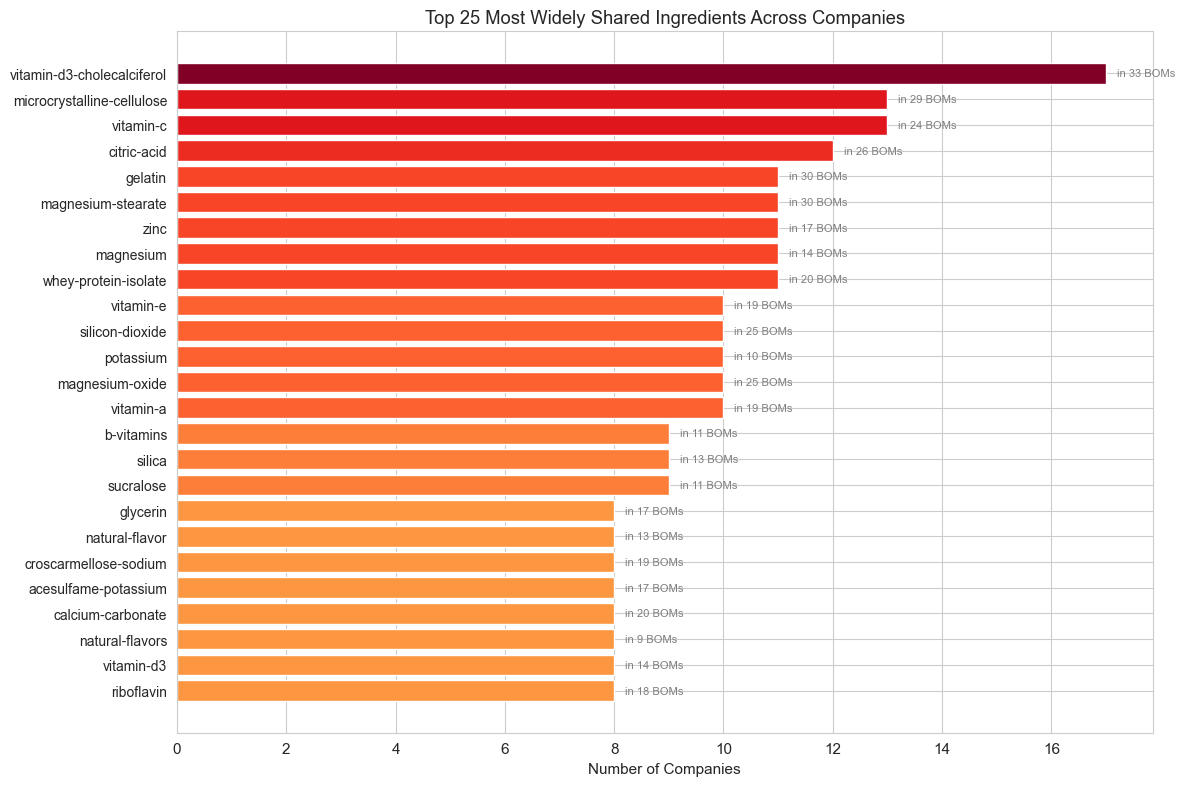

In [7]:
# Visualize: top 25 shared ingredients by number of companies
top_shared = shared.head(25).copy()

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.YlOrRd(top_shared["n_companies"] / top_shared["n_companies"].max())
bars = ax.barh(range(len(top_shared)), top_shared["n_companies"], color=colors)
ax.set_yticks(range(len(top_shared)))
ax.set_yticklabels(top_shared["ingredient"], fontsize=10)
ax.set_xlabel("Number of Companies")
ax.set_title("Top 25 Most Widely Shared Ingredients Across Companies")
ax.invert_yaxis()

for i, (nc, nb) in enumerate(zip(top_shared["n_companies"], top_shared["n_boms"])):
    ax.text(nc + 0.2, i, f"in {nb} BOMs", va="center", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

## 5. Ingredient Overlap by Category

Categorize ingredients and see which categories drive the most cross-company overlap. This reveals whether consolidation is strongest in vitamins, excipients, packaging, etc.

,n_ingredients,avg_companies,max_companies,total_bom_appearances
category,,,,
Vitamin/Mineral,66,5.2,17,617
Other,31,2.9,8,161
Excipient/Filler,12,5.8,13,144
Flavor/Sweetener,12,4.9,12,92
Oil/Fat/Emulsifier,10,3.8,8,77
Electrolyte/Salt,9,3.8,7,56
Protein/Amino Acid,2,9.5,11,37
Packaging/Capsule,1,11.0,11,30


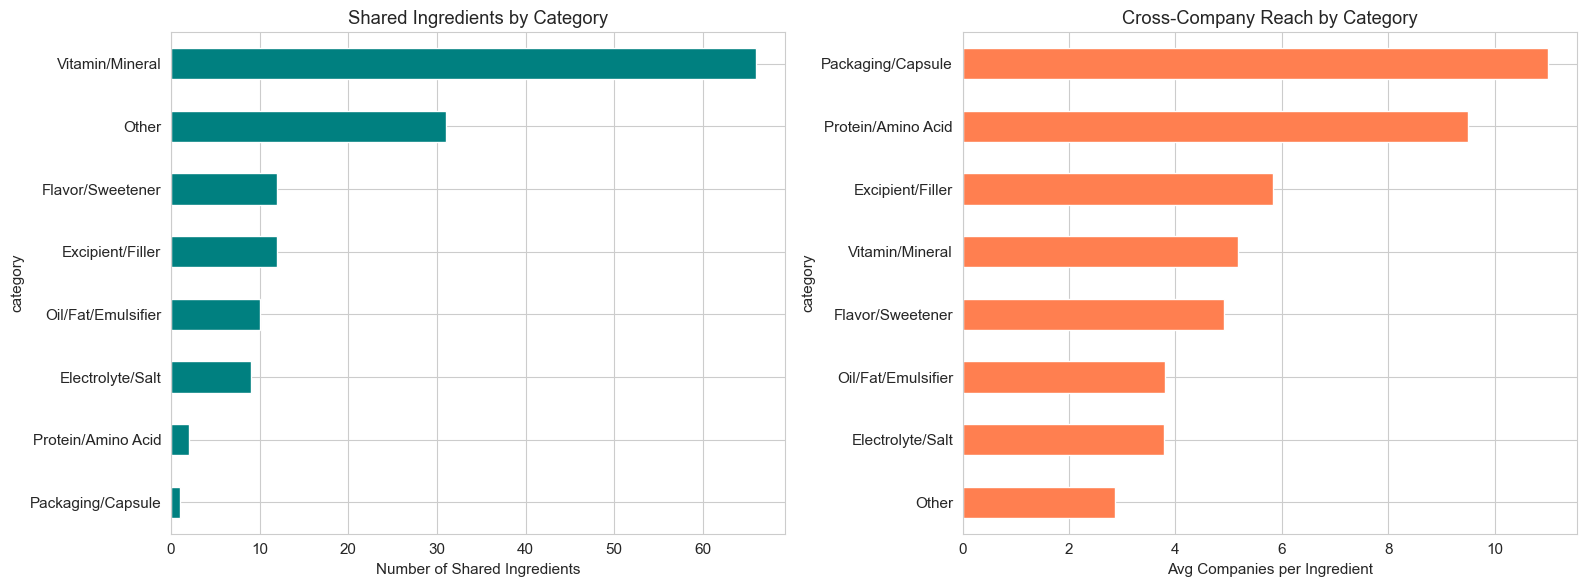

In [8]:
CATEGORIES = {
    "Vitamin/Mineral": ["vitamin", "mineral", "calcium", "magnesium", "zinc", "iron",
                        "potassium", "selenium", "manganese", "copper", "chromium",
                        "molybdenum", "iodine", "biotin", "folate", "folic", "niacin",
                        "thiamin", "riboflavin", "pantothenic", "pyridoxine", "cobalamin",
                        "cholecalciferol", "tocopherol", "ascorb", "retinyl", "b-vitamin"],
    "Protein/Amino Acid": ["protein", "amino", "bcaa", "leucine", "glutamine", "creatine",
                           "collagen", "whey", "casein", "eaa"],
    "Packaging/Capsule": ["capsule", "bottle", "cap", "label", "tablet", "coating",
                          "gelatin", "carton", "pouch", "seal", "shrink"],
    "Excipient/Filler": ["cellulose", "stearate", "silica", "silicon", "starch",
                         "maltodextrin", "dextrin", "croscarmellose", "hydroxypropyl"],
    "Flavor/Sweetener": ["flavor", "sugar", "sweetener", "sucralose", "stevia",
                         "acesulfame", "citric-acid", "malic-acid", "cocoa"],
    "Oil/Fat/Emulsifier": ["oil", "fat", "lecithin", "glycerin", "mct"],
    "Electrolyte/Salt": ["sodium", "chloride", "electrolyte", "salt"],
}

def categorize(ingredient):
    lower = ingredient.lower()
    for cat, keywords in CATEGORIES.items():
        if any(kw in lower for kw in keywords):
            return cat
    return "Other"

shared["category"] = shared["ingredient"].apply(categorize)

# Category breakdown of shared ingredients
cat_summary = (
    shared.groupby("category")
    .agg(
        n_ingredients=("ingredient", "count"),
        avg_companies=("n_companies", "mean"),
        max_companies=("n_companies", "max"),
        total_bom_appearances=("n_boms", "sum")
    )
    .sort_values("total_bom_appearances", ascending=False)
)

display(cat_summary.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Number of shared ingredients per category
cat_summary["n_ingredients"].sort_values().plot.barh(ax=axes[0], color="teal")
axes[0].set_xlabel("Number of Shared Ingredients")
axes[0].set_title("Shared Ingredients by Category")

# Average companies per ingredient, by category
cat_summary["avg_companies"].sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_xlabel("Avg Companies per Ingredient")
axes[1].set_title("Cross-Company Reach by Category")

plt.tight_layout()
plt.show()

## 6. Company-Ingredient Bipartite Network

Visualize the connections between companies and highly-shared ingredients as a network. Edges connect a company to each ingredient it uses. Dense clusters indicate consolidation groups.

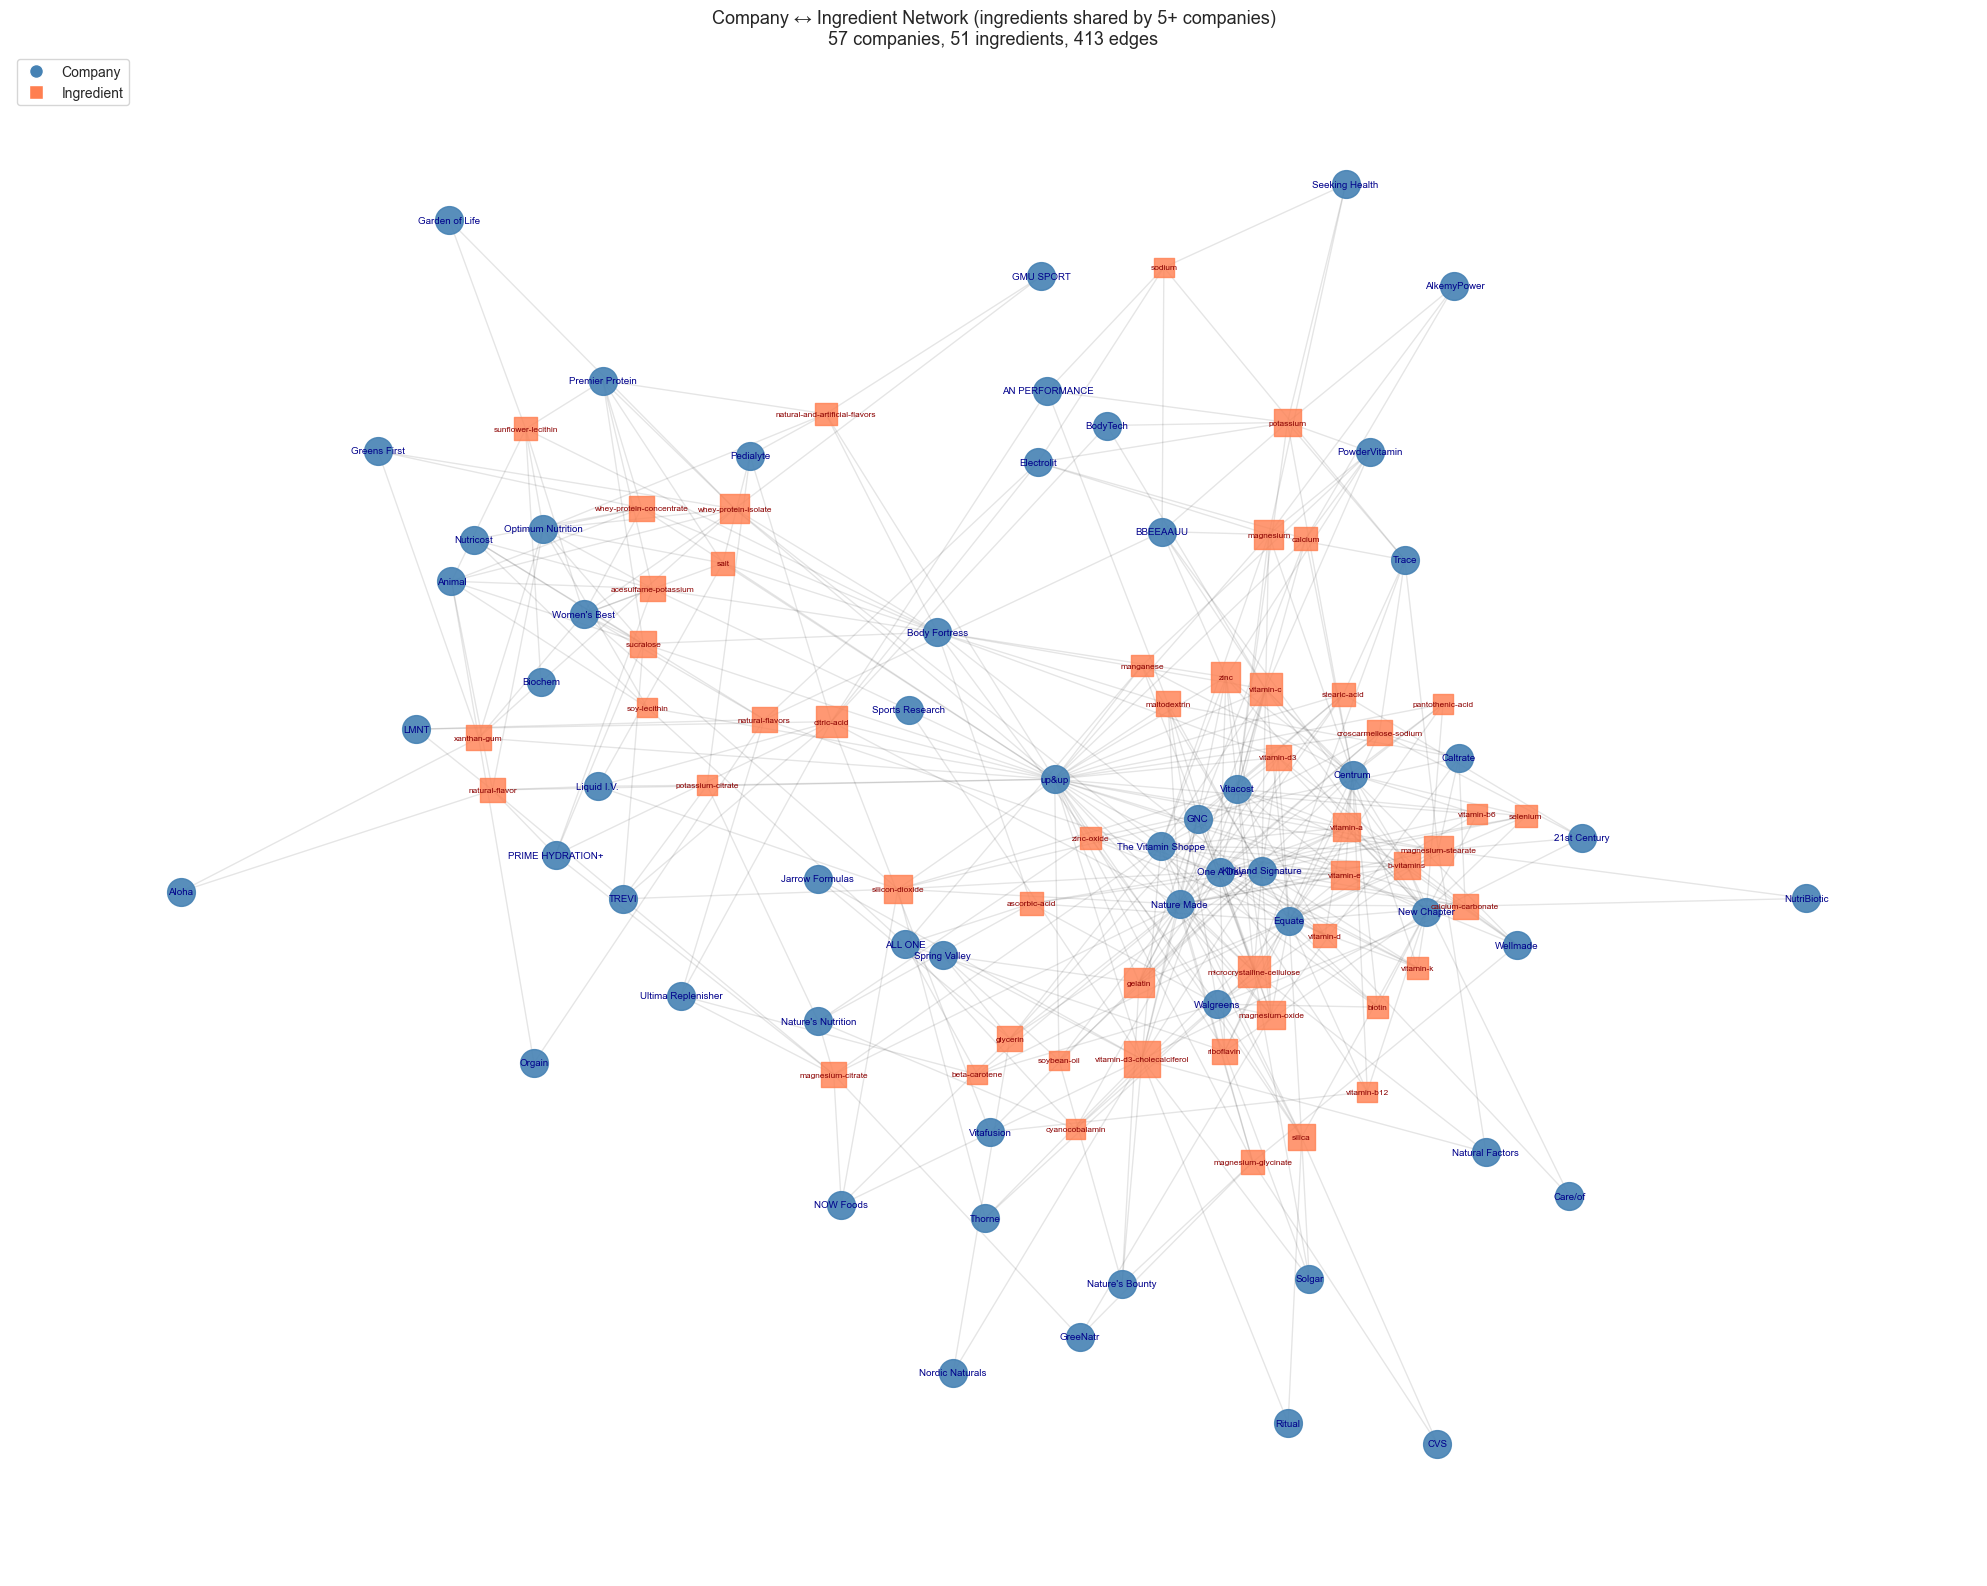

In [9]:
import networkx as nx
from networkx.algorithms import bipartite

# Only include ingredients shared by 5+ companies to keep the graph readable
high_overlap = shared[shared.n_companies >= 5]

G = nx.Graph()
for _, row in high_overlap.iterrows():
    ing = row["ingredient"]
    G.add_node(ing, bipartite=1, node_type="ingredient")
    for co in row["companies"]:
        G.add_node(co, bipartite=0, node_type="company")
        G.add_edge(co, ing)

company_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "company"]
ingredient_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "ingredient"]

fig, ax = plt.subplots(figsize=(20, 16))
pos = nx.spring_layout(G, k=0.4, iterations=80, seed=42)

# Draw company nodes
nx.draw_networkx_nodes(G, pos, nodelist=company_nodes, node_color="steelblue",
                       node_size=400, alpha=0.9, ax=ax)
# Draw ingredient nodes sized by how many companies use them
ing_sizes = [G.degree(n) * 40 for n in ingredient_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=ingredient_nodes, node_color="coral",
                       node_size=ing_sizes, alpha=0.8, ax=ax, node_shape="s")
# Edges
nx.draw_networkx_edges(G, pos, alpha=0.1, ax=ax)
# Labels
nx.draw_networkx_labels(G, pos, labels={n: n for n in company_nodes},
                        font_size=7, font_color="darkblue", ax=ax)
nx.draw_networkx_labels(G, pos, labels={n: n for n in ingredient_nodes},
                        font_size=6, font_color="darkred", ax=ax)

ax.set_title(f"Company ↔ Ingredient Network (ingredients shared by 5+ companies)\n"
             f"{len(company_nodes)} companies, {len(ingredient_nodes)} ingredients, {G.number_of_edges()} edges",
             fontsize=13)
ax.legend(handles=[
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=10, label="Company"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="coral", markersize=10, label="Ingredient"),
], loc="upper left", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Fragmentation Analysis: Same Ingredient, Different Suppliers

The core consolidation opportunity: when multiple companies buy the same ingredient but from *different* suppliers, there's a chance to consolidate under fewer suppliers for volume leverage.

Top 20 shared ingredients — supplier fragmentation:


,ingredient,n_companies,n_suppliers,fragmentation
134,vitamin-d3-cholecalciferol,17,2,0.12
64,microcrystalline-cellulose,13,2,0.15
131,vitamin-c,13,2,0.15
21,citric-acid,12,2,0.17
51,magnesium,11,2,0.18
141,zinc,11,2,0.18
40,gelatin,11,2,0.18
139,whey-protein-isolate,11,2,0.18
57,magnesium-stearate,11,2,0.18
102,silicon-dioxide,10,2,0.20


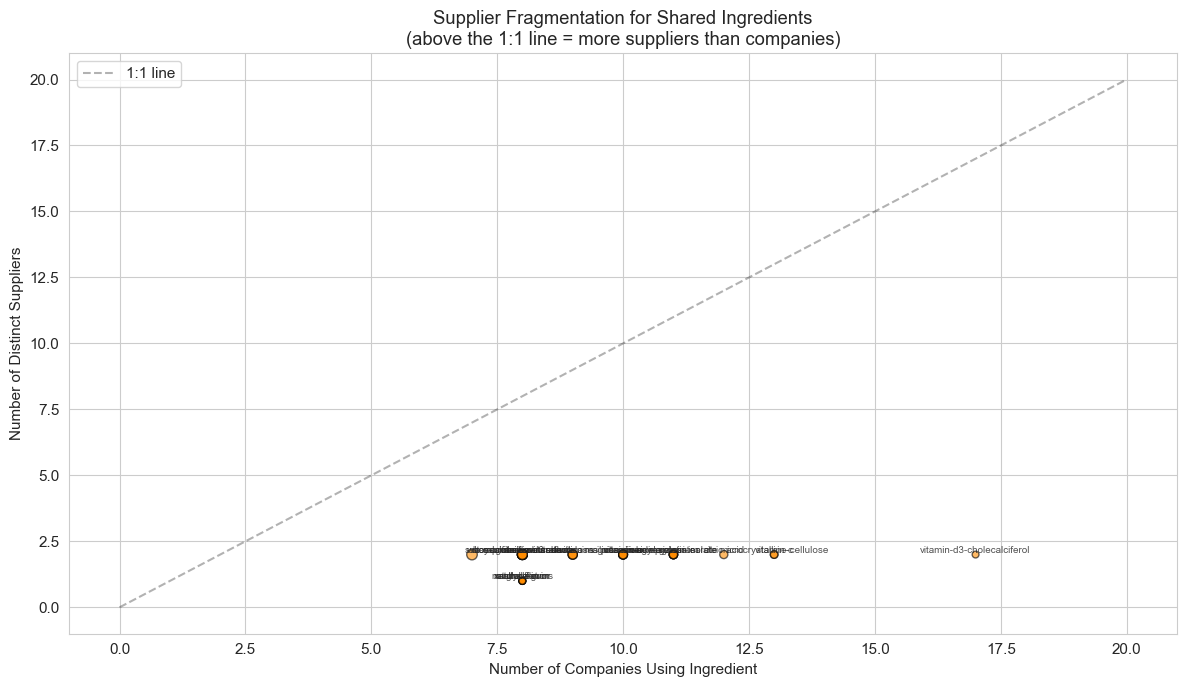

In [10]:
# For each shared ingredient, find which suppliers provide it per company
rm_suppliers = (
    supplier_product
    .merge(product, left_on="ProductId", right_on="Id")
    .merge(supplier, left_on="SupplierId", right_on="Id", suffixes=("_prod", "_sup"))
)
rm_suppliers["ingredient"] = rm_suppliers["SKU"].apply(extract_ingredient)

# Link: ingredient -> company -> suppliers
bom_suppliers = (
    bom_full[["ingredient", "CompanyName", "ConsumedProductId"]].drop_duplicates()
    .merge(supplier_product, left_on="ConsumedProductId", right_on="ProductId", how="left")
    .merge(supplier, left_on="SupplierId", right_on="Id", how="left")
    .rename(columns={"Name": "SupplierName"})
)

# For each shared ingredient: how many distinct suppliers across all companies?
ingredient_supplier_diversity = (
    bom_suppliers[bom_suppliers.ingredient.isin(shared.ingredient)]
    .groupby("ingredient")
    .agg(
        n_companies=("CompanyName", "nunique"),
        n_suppliers=("SupplierName", "nunique"),
        suppliers=("SupplierName", lambda x: sorted(x.dropna().unique())),
    )
    .reset_index()
    .sort_values("n_companies", ascending=False)
)

# Fragmentation score: many suppliers relative to the number of companies
ingredient_supplier_diversity["fragmentation"] = (
    ingredient_supplier_diversity["n_suppliers"] / ingredient_supplier_diversity["n_companies"]
).round(2)

print("Top 20 shared ingredients — supplier fragmentation:")
display(ingredient_supplier_diversity.head(20)[["ingredient", "n_companies", "n_suppliers", "fragmentation"]])

fig, ax = plt.subplots(figsize=(12, 7))
top_frag = ingredient_supplier_diversity.head(30)
ax.scatter(top_frag.n_companies, top_frag.n_suppliers,
           s=top_frag.fragmentation * 200, alpha=0.6, c="darkorange", edgecolors="black")
for _, r in top_frag.iterrows():
    ax.annotate(r["ingredient"], (r["n_companies"], r["n_suppliers"]),
                fontsize=7, alpha=0.8, ha="center", va="bottom")
ax.set_xlabel("Number of Companies Using Ingredient")
ax.set_ylabel("Number of Distinct Suppliers")
ax.plot([0, 20], [0, 20], "k--", alpha=0.3, label="1:1 line")
ax.set_title("Supplier Fragmentation for Shared Ingredients\n(above the 1:1 line = more suppliers than companies)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Company-to-Company Overlap Drilldown

For the top company pairs with highest overlap, show exactly which ingredients they share — these are the actionable consolidation lists.

In [11]:
# Build ingredient sets per company
company_ingredients = (
    bom_full[["CompanyName", "ingredient"]]
    .drop_duplicates()
    .groupby("CompanyName")["ingredient"]
    .apply(set)
    .to_dict()
)

# Drill into top 10 pairs
top10_pairs = pairs_df.head(10)
for _, row in top10_pairs.iterrows():
    a, b = row["Company A"], row["Company B"]
    shared_set = company_ingredients[a] & company_ingredients[b]
    only_a = company_ingredients[a] - company_ingredients[b]
    only_b = company_ingredients[b] - company_ingredients[a]

    print(f"\n{'='*70}")
    print(f"{a}  ↔  {b}")
    print(f"  Jaccard: {row['Jaccard Similarity']:.3f}  |  Shared: {len(shared_set)}  |  Only {a}: {len(only_a)}  |  Only {b}: {len(only_b)}")
    print(f"  Shared ingredients: {', '.join(sorted(shared_set))}")


Animal  ↔  Optimum Nutrition
  Jaccard: 0.588  |  Shared: 10  |  Only Animal: 3  |  Only Optimum Nutrition: 4
  Shared ingredients: acesulfame-potassium, artificial-flavor, cellulose-gum, natural-flavor, soy-lecithin, sucralose, sunflower-lecithin, whey-protein-concentrate, whey-protein-isolate, xanthan-gum

Premier Protein  ↔  Women's Best
  Jaccard: 0.545  |  Shared: 6  |  Only Premier Protein: 1  |  Only Women's Best: 4
  Shared ingredients: acesulfame-potassium, salt, sucralose, sunflower-lecithin, whey-protein-concentrate, whey-protein-isolate

Optimum Nutrition  ↔  Premier Protein
  Jaccard: 0.500  |  Shared: 7  |  Only Optimum Nutrition: 7  |  Only Premier Protein: 0
  Shared ingredients: acesulfame-potassium, natural-and-artificial-flavors, salt, sucralose, sunflower-lecithin, whey-protein-concentrate, whey-protein-isolate

AlkemyPower  ↔  Electrolit
  Jaccard: 0.500  |  Shared: 3  |  Only AlkemyPower: 0  |  Only Electrolit: 3
  Shared ingredients: calcium, magnesium, potassiu

## 9. Overlap Heatmap: Companies vs Top Shared Ingredients

A focused heatmap showing only the most widely shared ingredients (10+ companies), revealing which companies participate in each overlap pocket.

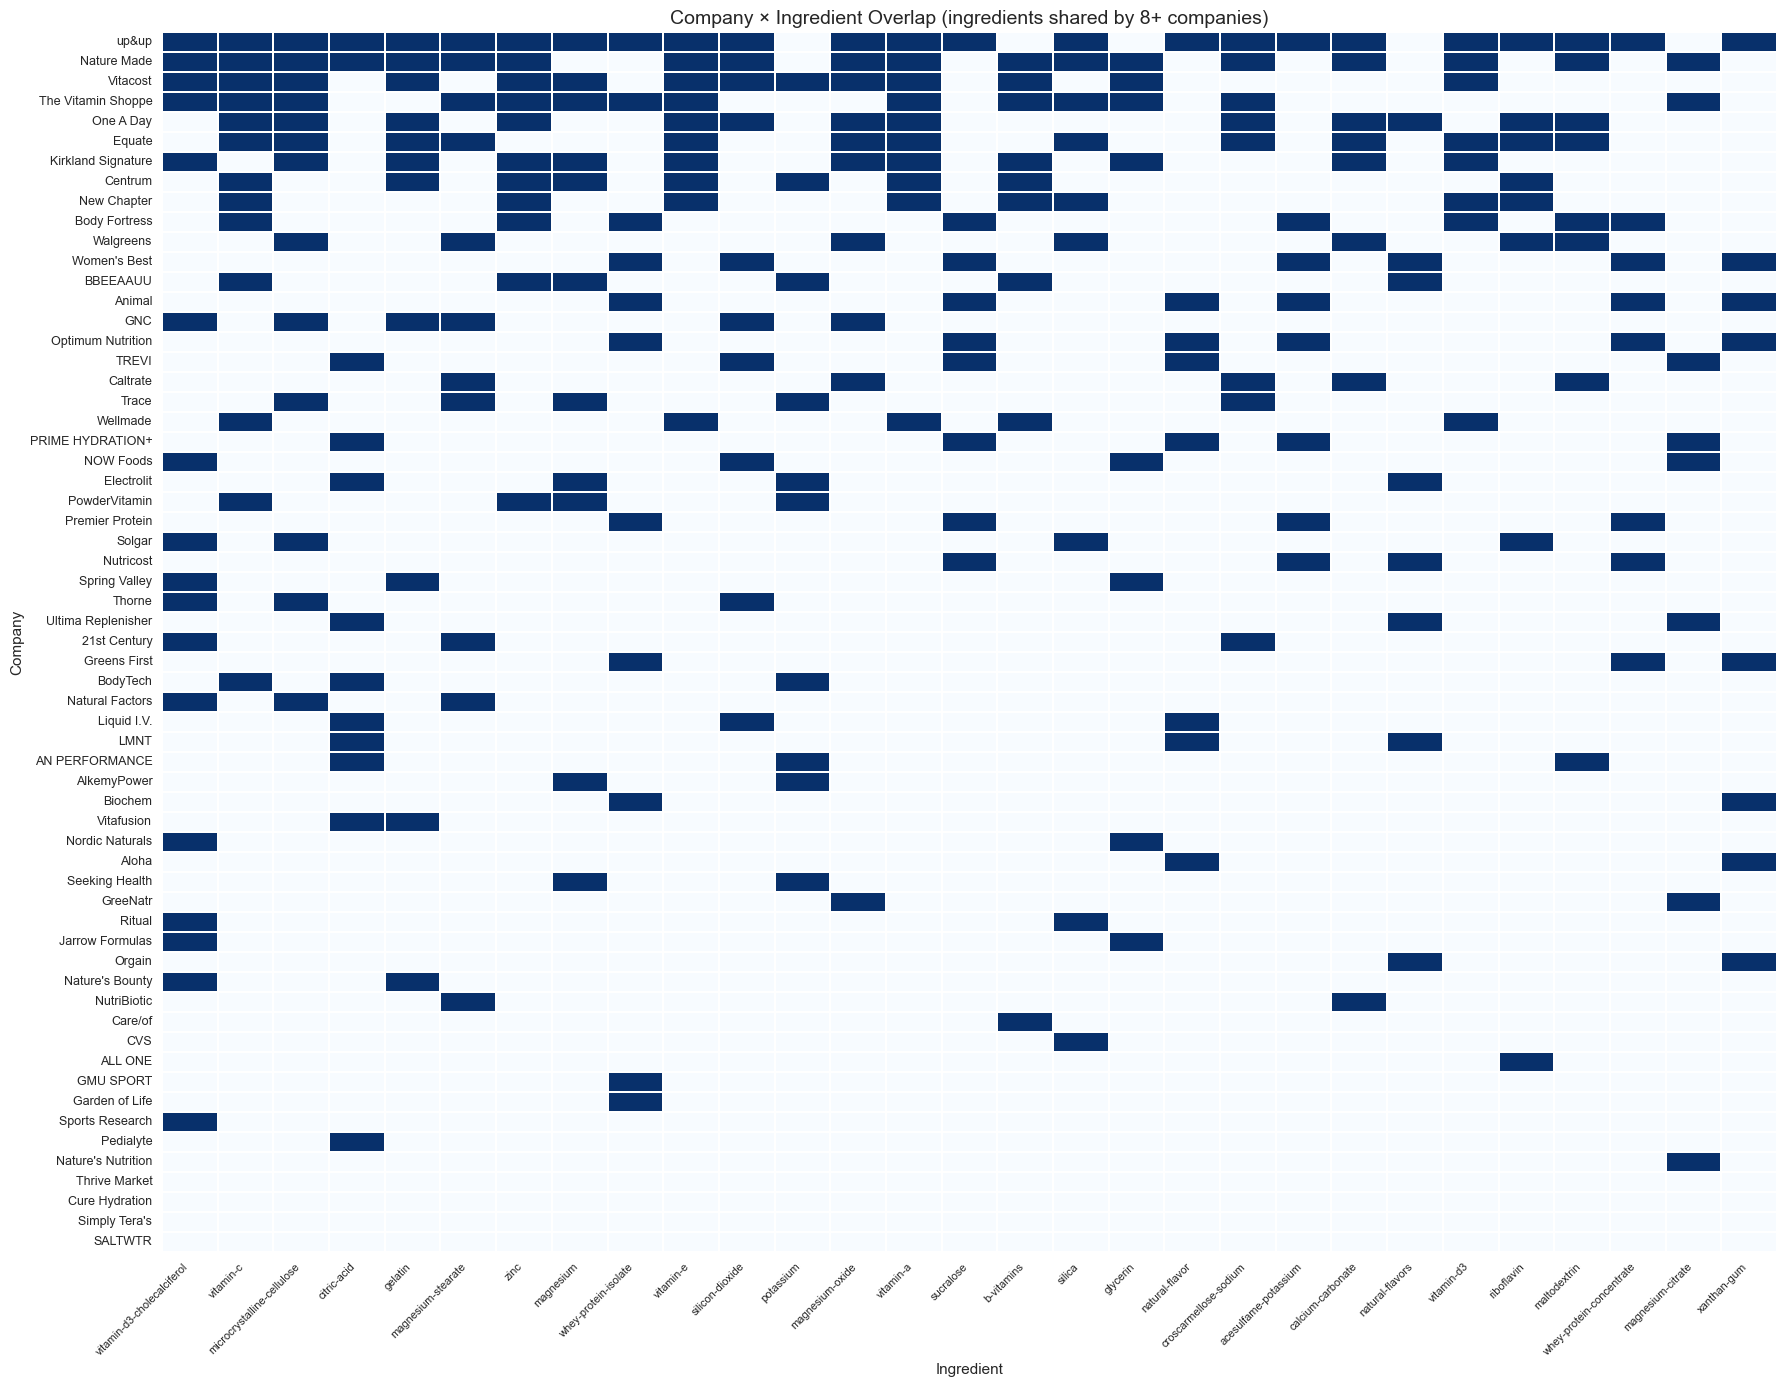

Showing 29 ingredients across 61 companies


In [12]:
# Filter to ingredients used by 8+ companies
hot_ingredients = shared[shared.n_companies >= 8]["ingredient"].tolist()
hot_matrix = company_ingredient[hot_ingredients].copy()

# Sort companies by total usage of hot ingredients (most active first)
hot_matrix = hot_matrix.loc[hot_matrix.sum(axis=1).sort_values(ascending=False).index]

# Sort ingredients by how many companies use them
hot_matrix = hot_matrix[hot_matrix.sum(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(hot_matrix, cmap="Blues", cbar=False, linewidths=0.3,
            linecolor="white", ax=ax, square=False)
ax.set_title(f"Company × Ingredient Overlap (ingredients shared by 8+ companies)", fontsize=14)
ax.set_xlabel("Ingredient")
ax.set_ylabel("Company")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Showing {len(hot_ingredients)} ingredients across {len(hot_matrix)} companies")

## 10. Consolidation Opportunity Score

Rank ingredients by a composite score combining: how many companies use them, how many BOMs they appear in, and how fragmented the supplier base is. High score = high-value consolidation target.

Top 25 Consolidation Opportunities:


,ingredient,category,n_companies,n_boms,n_suppliers,opportunity_score
0,vitamin-d3-cholecalciferol,Vitamin/Mineral,17,33,2,0.800
1,microcrystalline-cellulose,Excipient/Filler,13,29,2,0.655
4,gelatin,Packaging/Capsule,11,30,2,0.611
5,magnesium-stearate,Vitamin/Mineral,11,30,2,0.611
2,vitamin-c,Vitamin/Mineral,13,24,2,0.606
3,citric-acid,Flavor/Sweetener,12,26,2,0.599
12,magnesium-oxide,Vitamin/Mineral,10,25,2,0.536
10,silicon-dioxide,Excipient/Filler,10,25,2,0.536
8,whey-protein-isolate,Protein/Amino Acid,11,20,2,0.514
6,zinc,Vitamin/Mineral,11,17,2,0.485


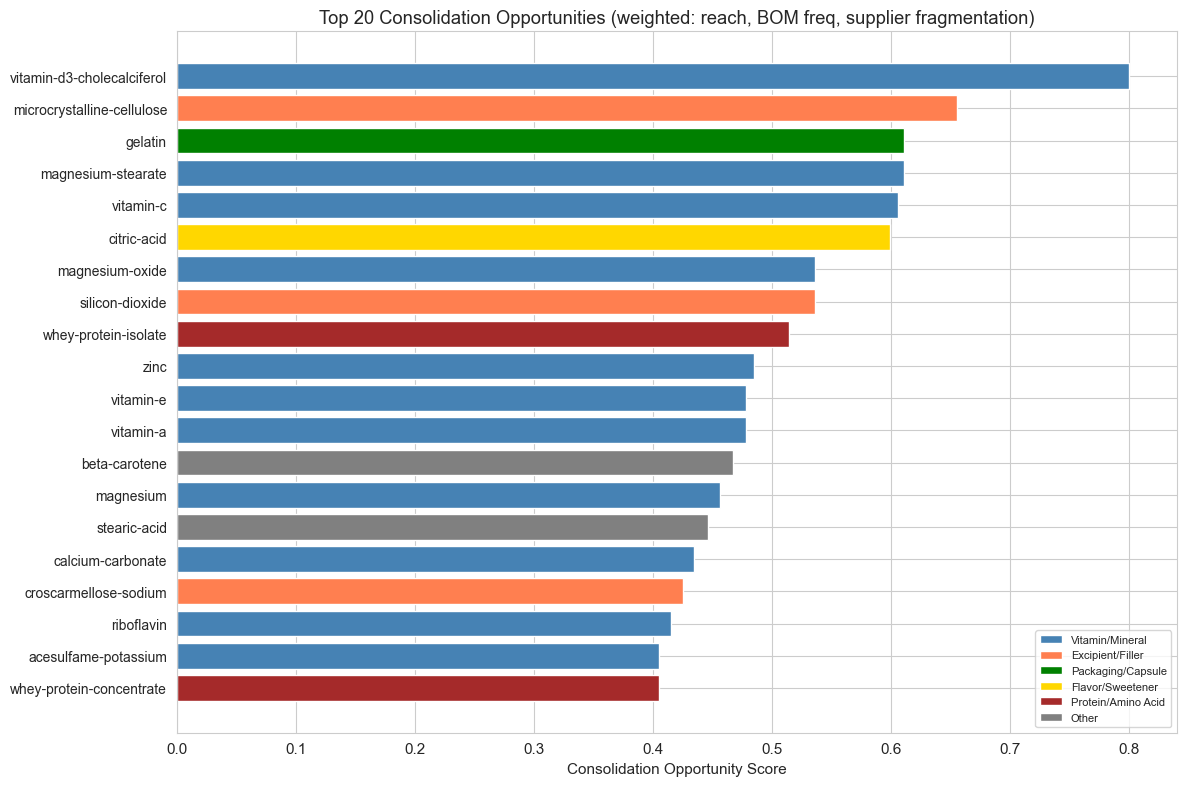

In [13]:
# Merge ingredient stats with supplier diversity
opportunity = (
    shared[["ingredient", "n_companies", "n_boms", "category"]]
    .merge(
        ingredient_supplier_diversity[["ingredient", "n_suppliers", "fragmentation"]],
        on="ingredient", how="left"
    )
)
opportunity["n_suppliers"] = opportunity["n_suppliers"].fillna(0).astype(int)

# Normalize each factor to 0-1 range, then sum for a composite score
for col in ["n_companies", "n_boms", "n_suppliers"]:
    opportunity[f"{col}_norm"] = (opportunity[col] - opportunity[col].min()) / (opportunity[col].max() - opportunity[col].min())

opportunity["opportunity_score"] = (
    opportunity["n_companies_norm"] * 0.4 +   # cross-company reach
    opportunity["n_boms_norm"] * 0.3 +         # BOM frequency
    opportunity["n_suppliers_norm"] * 0.3      # supplier fragmentation
).round(3)

opportunity = opportunity.sort_values("opportunity_score", ascending=False)

print("Top 25 Consolidation Opportunities:")
display(opportunity.head(25)[["ingredient", "category", "n_companies", "n_boms", "n_suppliers", "opportunity_score"]])

fig, ax = plt.subplots(figsize=(12, 8))
top_opp = opportunity.head(20)
colors = {"Vitamin/Mineral": "steelblue", "Excipient/Filler": "coral", "Packaging/Capsule": "green",
          "Flavor/Sweetener": "gold", "Oil/Fat/Emulsifier": "purple", "Protein/Amino Acid": "brown",
          "Electrolyte/Salt": "teal", "Other": "gray"}
bar_colors = [colors.get(c, "gray") for c in top_opp["category"]]

ax.barh(range(len(top_opp)), top_opp["opportunity_score"], color=bar_colors)
ax.set_yticks(range(len(top_opp)))
ax.set_yticklabels(top_opp["ingredient"], fontsize=10)
ax.set_xlabel("Consolidation Opportunity Score")
ax.set_title("Top 20 Consolidation Opportunities (weighted: reach, BOM freq, supplier fragmentation)")
ax.invert_yaxis()

# Legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in colors.items() if cat in top_opp["category"].values]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## 11. Cluster-Level Consolidation Summary

For each cluster from section 3, show the shared ingredient core (ingredients used by a majority of cluster members) and the potential supplier consolidation within that cluster.

In [14]:
# For each cluster, find the "core" ingredients used by >50% of members
for c in sorted(cluster_map.Cluster.unique()):
    members = cluster_map[cluster_map.Cluster == c]["Company"].tolist()
    if len(members) < 2:
        continue

    # Subset the company-ingredient matrix to cluster members
    cluster_mat = company_ingredient.loc[company_ingredient.index.isin(members)]
    usage_fraction = cluster_mat.sum(axis=0) / len(members)
    core = usage_fraction[usage_fraction > 0.5].sort_values(ascending=False)

    print(f"\n{'='*70}")
    print(f"CLUSTER {c} — {len(members)} companies: {', '.join(members)}")
    print(f"  Core ingredients (used by >50% of cluster): {len(core)}")
    if len(core) > 0:
        for ing, frac in core.head(15).items():
            print(f"    {ing:40s}  ({frac:.0%} of cluster)")
        if len(core) > 15:
            print(f"    ... and {len(core) - 15} more")


CLUSTER 1 — 6 companies: Body Fortress, Women's Best, Optimum Nutrition, Nutricost, Animal, Premier Protein
  Core ingredients (used by >50% of cluster): 6
    acesulfame-potassium                      (100% of cluster)
    sucralose                                 (100% of cluster)
    whey-protein-concentrate                  (100% of cluster)
    sunflower-lecithin                        (83% of cluster)
    whey-protein-isolate                      (83% of cluster)
    salt                                      (67% of cluster)

CLUSTER 2 — 9 companies: PowderVitamin, Trace, BodyTech, Electrolit, BBEEAAUU, AlkemyPower, AN PERFORMANCE, Vitafusion, Seeking Health
  Core ingredients (used by >50% of cluster): 3
    potassium                                 (89% of cluster)
    magnesium                                 (67% of cluster)
    sodium                                    (56% of cluster)

CLUSTER 3 — 11 companies: One A Day, Kirkland Signature, Nature Made, up&up, Equate, The

## 12. Summary Statistics

In [15]:
unique_ingredients = bom_full["ingredient"].nunique()
shared_2plus = len(shared)
shared_5plus = (shared.n_companies >= 5).sum()
shared_10plus = (shared.n_companies >= 10).sum()
avg_jaccard = pairs_df["Jaccard Similarity"].mean()
max_jaccard = pairs_df.iloc[0]
n_pairs_above_20 = (pairs_df["Jaccard Similarity"] >= 0.2).sum()

print("=" * 60)
print("CROSS-COMPANY INGREDIENT OVERLAP — KEY FINDINGS")
print("=" * 60)
print(f"Total unique ingredients:              {unique_ingredients}")
print(f"Shared across 2+ companies:            {shared_2plus} ({shared_2plus/unique_ingredients:.0%})")
print(f"Shared across 5+ companies:            {shared_5plus}")
print(f"Shared across 10+ companies:           {shared_10plus}")
print()
print(f"Company pairs analyzed:                {len(pairs_df)}")
print(f"Avg pairwise Jaccard similarity:       {avg_jaccard:.3f}")
print(f"Most similar pair:                     {max_jaccard['Company A']} ↔ {max_jaccard['Company B']} (J={max_jaccard['Jaccard Similarity']:.3f})")
print(f"Pairs with Jaccard >= 0.2:             {n_pairs_above_20}")
print()
print("CONSOLIDATION PRIORITIES:")
print(f"  1. {shared_10plus} ingredients shared by 10+ companies — highest volume leverage")
print(f"  2. Top opportunity: {opportunity.iloc[0]['ingredient']} (score={opportunity.iloc[0]['opportunity_score']:.3f})")
print(f"  3. Most overlapping category: {cat_summary.index[0]}")
print(f"  4. {n_clusters} natural company clusters identified for joint procurement")

conn.close()

CROSS-COMPANY INGREDIENT OVERLAP — KEY FINDINGS
Total unique ingredients:              357
Shared across 2+ companies:            143 (40%)
Shared across 5+ companies:            51
Shared across 10+ companies:           14

Company pairs analyzed:                1830
Avg pairwise Jaccard similarity:       0.033
Most similar pair:                     Animal ↔ Optimum Nutrition (J=0.588)
Pairs with Jaccard >= 0.2:             65

CONSOLIDATION PRIORITIES:
  1. 14 ingredients shared by 10+ companies — highest volume leverage
  2. Top opportunity: vitamin-d3-cholecalciferol (score=0.800)
  3. Most overlapping category: Vitamin/Mineral
  4. 6 natural company clusters identified for joint procurement
